In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load raw data (never edited by hand after collection)
df = pd.read_csv("./dataset/sydney_sold.csv")

# Drop columns too empty to be useful
df = df.drop(columns=["building_size_m2", "sale_method"], errors="ignore")

In [3]:
# Standardise labels, then merge rare property types into 3 groups
df["property_type"] = df["property_type"].str.strip().str.lower()
type_map = {
    "apartment": "unit",
    "unit": "unit",
    "villa": "townhouse",
    "duplex/semi-detached": "townhouse",
    "townhouse": "townhouse",
    "house": "house",
}
df["property_type"] = df["property_type"].map(type_map)

# Parse dates; drop rows still missing core structural features
df["sale_date"] = pd.to_datetime(df["sale_date"])
df = df.dropna(subset=["bedrooms", "bathrooms", "car_spaces"])

print(df.shape)
print(df["property_type"].value_counts())
print(df.isna().sum())

(102, 10)
property_type
house        65
unit         24
townhouse    13
Name: count, dtype: int64
suburb            0
sale_date         0
price             0
property_type     0
bedrooms          0
bathrooms         0
car_spaces        0
land_size_m2     42
listing_url       0
description       0
dtype: int64


In [4]:
if "description" in df.columns:
    df = df.drop(columns=["description"])

/var/folders/5l/lwbb2j610p5cjxnzbc18gv900000gn/T/ipykernel_86527/3163486068.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df.loc[df["suburb"] == s, "price"] / 1e6 for s in order],


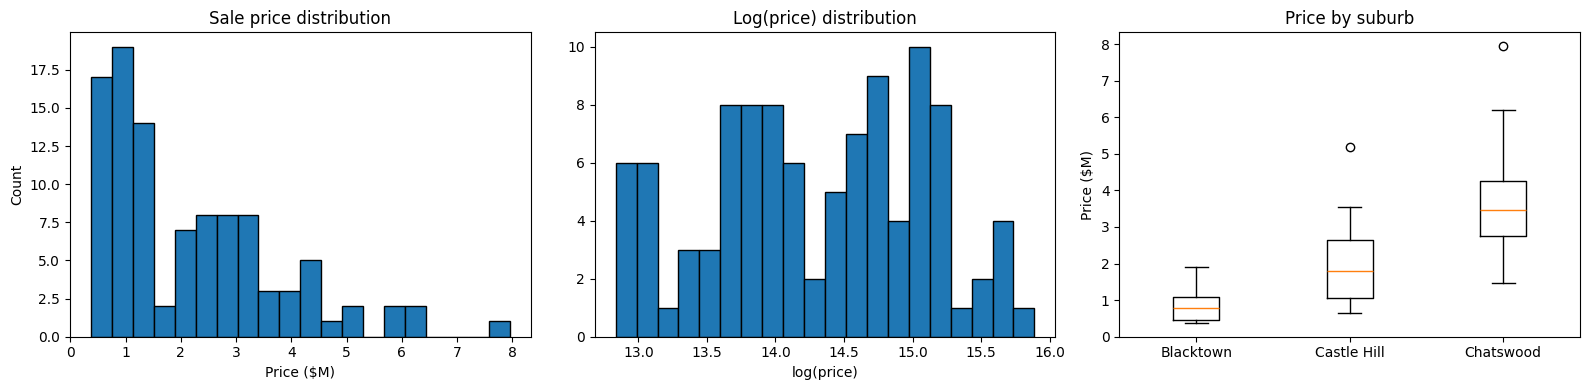

Skew (raw): 1.13
Skew (log): -0.15
             count     median      min      max
suburb                                         
Blacktown       35   790000.0   375000  1900000
Castle Hill     33  1800000.0   632000  5200000
Chatswood       34  3452500.0  1460000  7950000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Raw price distribution: checks for right skew
axes[0].hist(df["price"] / 1e6, bins=20, edgecolor="black")
axes[0].set(title="Sale price distribution", xlabel="Price ($M)", ylabel="Count")

# 2. Log price: checks whether the log makes it closer to symmetric
axes[1].hist(np.log(df["price"]), bins=20, edgecolor="black")
axes[1].set(title="Log(price) distribution", xlabel="log(price)")

# 3. Price by suburb: market differences and outliers (dots beyond whiskers)
order = ["Blacktown", "Castle Hill", "Chatswood"]
axes[2].boxplot([df.loc[df["suburb"] == s, "price"] / 1e6 for s in order],
                labels=order)
axes[2].set(title="Price by suburb", ylabel="Price ($M)")

plt.tight_layout()
plt.show()

print("Skew (raw):", round(df["price"].skew(), 2))
print("Skew (log):", round(np.log(df["price"]).skew(), 2))
print(df.groupby("suburb")["price"].agg(["count", "median", "min", "max"]))

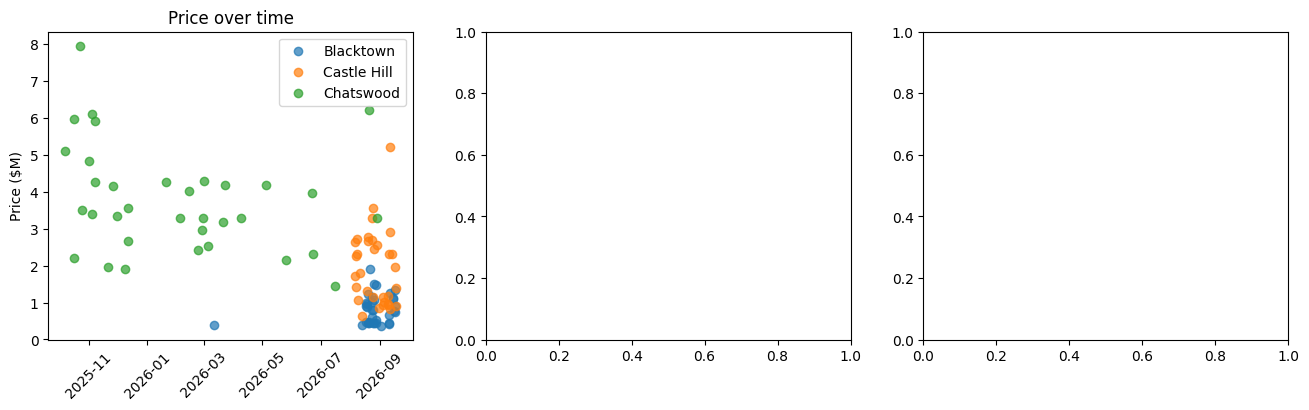

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {"Blacktown": "tab:blue", "Castle Hill": "tab:orange", "Chatswood": "tab:green"}

# 1. Price over time by suburb: checks for market trend
for s, g in df.groupby("suburb"):
    axes[0].scatter(g["sale_date"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[0].set(title="Price over time", ylabel="Price ($M)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

[Text(0.5, 1.0, 'Land size vs price'),
 Text(0.5, 0, 'Land size (m²)'),
 Text(0, 0.5, 'Price ($M)')]

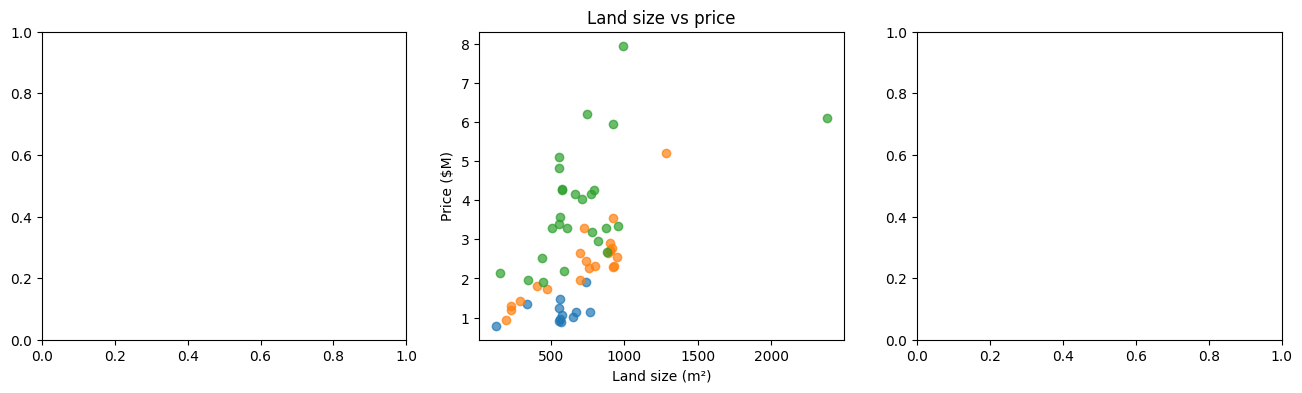

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {"Blacktown": "tab:blue", "Castle Hill": "tab:orange", "Chatswood": "tab:green"}

# 2. Land size vs price (houses/townhouses only; units have no land size)
for s, g in df.dropna(subset=["land_size_m2"]).groupby("suburb"):
    axes[1].scatter(g["land_size_m2"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[1].set(title="Land size vs price", xlabel="Land size (m²)", ylabel="Price ($M)")

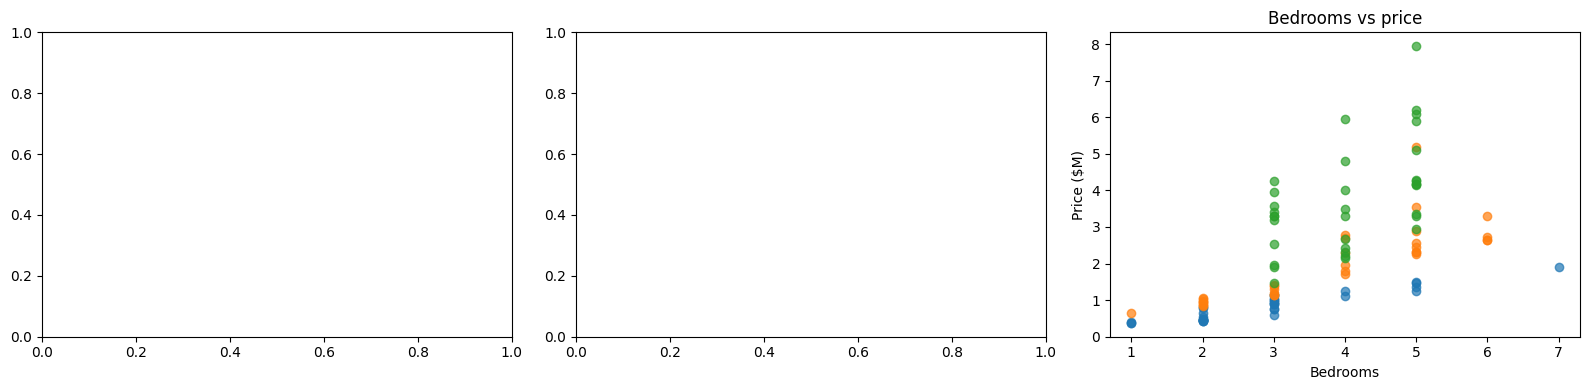

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {"Blacktown": "tab:blue", "Castle Hill": "tab:orange", "Chatswood": "tab:green"}
# 3. Bedrooms vs price
for s, g in df.groupby("suburb"):
    axes[2].scatter(g["bedrooms"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[2].set(title="Bedrooms vs price", xlabel="Bedrooms", ylabel="Price ($M)")

plt.tight_layout()
plt.show()

In [9]:
# Monthly sales count: shows how uneven the time coverage is
print(df["sale_date"].dt.to_period("M").value_counts().sort_index())

sale_date
2025-10     5
2025-11     7
2025-12     4
2026-01     1
2026-02     5
2026-03     5
2026-04     1
2026-05     2
2026-06     2
2026-07     1
2026-08    44
2026-09    25
Freq: M, Name: count, dtype: int64


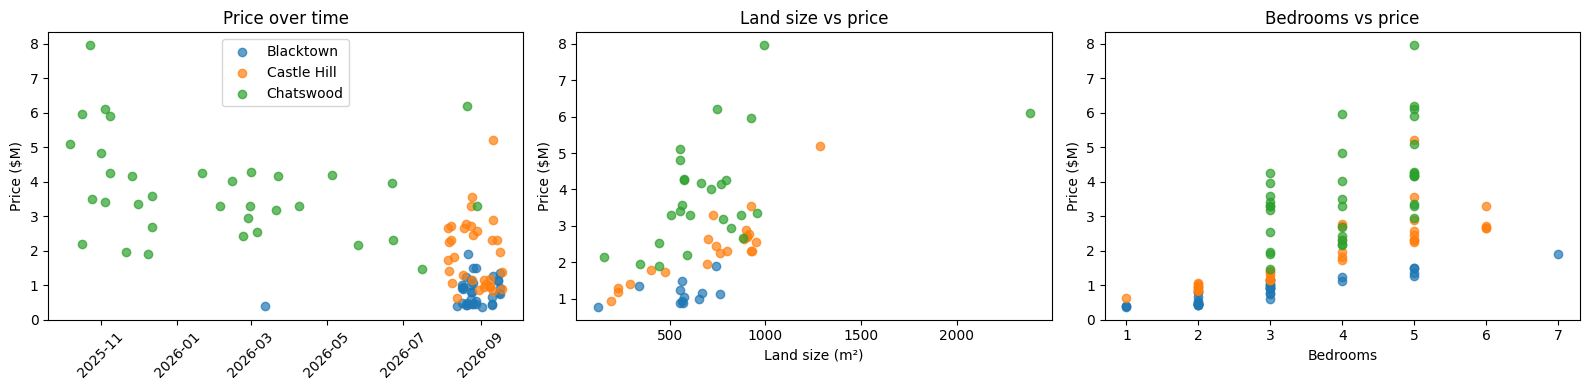

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {"Blacktown": "tab:blue", "Castle Hill": "tab:orange", "Chatswood": "tab:green"}

# 1. Price over time by suburb: checks for market trend
for s, g in df.groupby("suburb"):
    axes[0].scatter(g["sale_date"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[0].set(title="Price over time", ylabel="Price ($M)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# 2. Land size vs price (houses/townhouses only; units have no land size)
for s, g in df.dropna(subset=["land_size_m2"]).groupby("suburb"):
    axes[1].scatter(g["land_size_m2"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[1].set(title="Land size vs price", xlabel="Land size (m²)", ylabel="Price ($M)")

# 3. Bedrooms vs price
for s, g in df.groupby("suburb"):
    axes[2].scatter(g["bedrooms"], g["price"] / 1e6, label=s, c=colors[s], alpha=0.7)
axes[2].set(title="Bedrooms vs price", xlabel="Bedrooms", ylabel="Price ($M)")

plt.tight_layout()
plt.show()

MY obj:

My three predicted features are suburb, land size and bedrooms. I chose suburb because the plots show a very clear separation in prices between Chatswood, Castle Hill and Blacktown. I chose land size because larger blocks generally appear to sell for more, although there is some variation. Finally, I chose bedrooms because properties with more bedrooms tend to appear at higher price levels. These are my initial hypotheses based on the visual patterns, and I would then test whether the data actually supports them rather than assuming correlation means causation.

In [11]:
# Units have no private land: 0 is the true value, not a missing one
df.loc[df["property_type"] == "unit", "land_size_m2"] = 0

# Log transforms: compress the long right tails
df["log_land"] = np.log1p(df["land_size_m2"])   # 12 houses stay NaN -> imputed in pipeline
df["log_price"] = np.log(df["price"])           # modelling target

In [12]:
# Features: sale_date excluded, listing_url is an ID
cat_features = ["suburb", "property_type"]
num_features = ["bedrooms", "bathrooms", "car_spaces", "log_land"]

X = df[cat_features + num_features]
y = df["log_price"]

In [13]:
# Quick evidence check for the three hypotheses
print("Spearman correlation with log_price:")
print(df[num_features + ["log_price"]].corr(method="spearman")["log_price"]
      .drop("log_price").sort_values(ascending=False).round(2))
print("\nMedian log_price by suburb:")
print(df.groupby("suburb")["log_price"].median().round(2))
print("\nbedrooms vs log_land correlation:",
      round(df[["bedrooms", "log_land"]].corr(method="spearman").iloc[0, 1], 2))

Spearman correlation with log_price:
log_land      0.79
bedrooms      0.77
bathrooms     0.64
car_spaces    0.55
Name: log_price, dtype: float64

Median log_price by suburb:
suburb
Blacktown      13.58
Castle Hill    14.40
Chatswood      15.05
Name: log_price, dtype: float64

bedrooms vs log_land correlation: 0.81


Everything was on point and found:

Unexpected finding: bathrooms (0.64) is also strong. Mention it as something you didn't predict.

Modal selection:

        I chose these three models because they represent **three different modelling approaches**: Ridge provides a simple linear baseline, KNN predicts from similar properties, and Random Forest can capture nonlinear relationships and interactions. **I expect Random Forest to perform best** because property prices likely depend on nonlinear effects and interactions between suburb, land size, and bedrooms, although the small dataset may increase its risk of overfitting.


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error

# Preprocessing is fitted inside each fold, so there is no leakage
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), num_features),
])

models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42),
}

# Dollar-scale MAE: convert log predictions back to prices before scoring
def dollar_mae(y_true, y_pred):
    return mean_absolute_error(np.exp(y_true), np.exp(y_pred))

scoring = {
    "mae_log": "neg_mean_absolute_error",
    "rmse_log": "neg_root_mean_squared_error",
    "r2": "r2",
    "mae_dollars": make_scorer(dollar_mae, greater_is_better=False),
}

In [15]:
# 5 folds x 5 repeats: repeating reduces the noise of any single split on ~100 rows
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=True)
    rows.append({
        "Model": name,
        "Train R²": res["train_r2"].mean(),
        "CV R²": res["test_r2"].mean(),
        "CV R² std": res["test_r2"].std(),
        "CV MAE (log)": -res["test_mae_log"].mean(),
        "CV RMSE (log)": -res["test_rmse_log"].mean(),
        "Train MAE ($)": -res["train_mae_dollars"].mean(),
        "CV MAE ($)": -res["test_mae_dollars"].mean(),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
print(results.to_string())

                 Train R²  CV R²  CV R² std  CV MAE (log)  CV RMSE (log)  Train MAE ($)   CV MAE ($)
Model                                                                                               
Baseline (mean)     0.000 -0.090      0.114         0.690          0.792    1262755.842  1281712.537
Ridge               0.946  0.925      0.028         0.153          0.205     363147.835   413670.917
KNN                 0.885  0.785      0.101         0.251          0.342     474018.196   617128.630
Random Forest       0.989  0.917      0.035         0.156          0.214     164133.123   425070.840


Ridge (alpha: higher = simpler): best alpha = 1, CV R² = 0.920
KNN (k: higher = simpler): best n_neighbors = 3, CV R² = 0.801
Random Forest (min leaf size: higher = simpler): best min_samples_leaf = 1, CV R² = 0.913


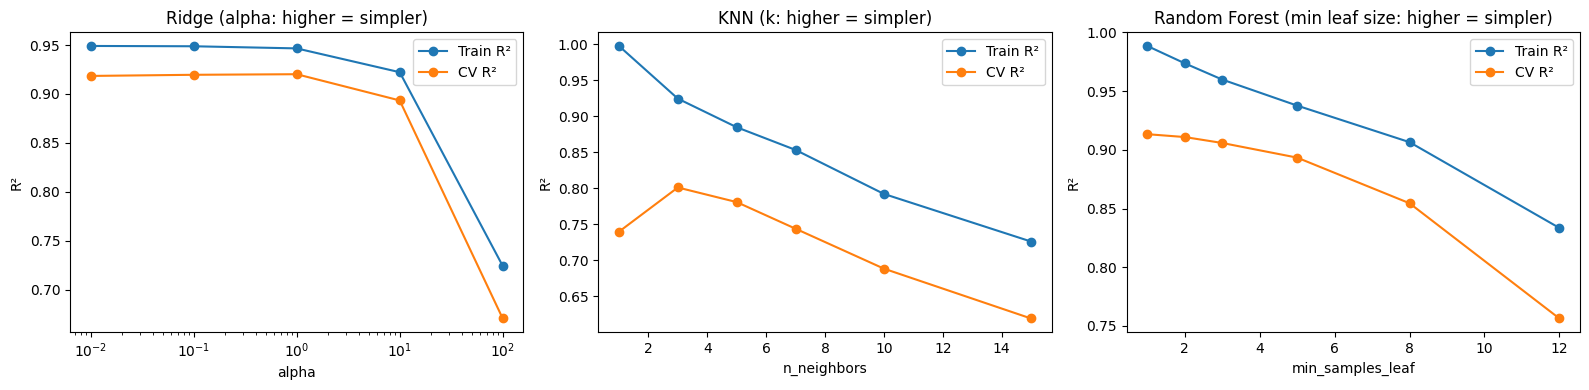

In [16]:
from sklearn.model_selection import validation_curve

cv_small = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# (model, parameter name inside pipeline, values to try, use log x-axis?)
curves = {
    "Ridge (alpha: higher = simpler)": (Ridge(), "model__alpha",
                                       [0.01, 0.1, 1, 10, 100], True),
    "KNN (k: higher = simpler)": (KNeighborsRegressor(), "model__n_neighbors",
                                  [1, 3, 5, 7, 10, 15], False),
    "Random Forest (min leaf size: higher = simpler)":
        (RandomForestRegressor(n_estimators=300, random_state=42),
         "model__min_samples_leaf", [1, 2, 3, 5, 8, 12], False),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, (model, param, values, log_x)) in zip(axes, curves.items()):
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    train_sc, cv_sc = validation_curve(pipe, X, y, param_name=param,
                                       param_range=values, cv=cv_small, scoring="r2")
    ax.plot(values, train_sc.mean(axis=1), "o-", label="Train R²")
    ax.plot(values, cv_sc.mean(axis=1), "o-", label="CV R²")
    ax.set(title=title, xlabel=param.split("__")[1], ylabel="R²")
    if log_x:
        ax.set_xscale("log")
    ax.legend()
    best = values[cv_sc.mean(axis=1).argmax()]
    print(f"{title}: best {param.split('__')[1]} = {best}, "
          f"CV R² = {cv_sc.mean(axis=1).max():.3f}")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import KFold, cross_val_predict

best_model = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])

# Out-of-fold predictions: each property is predicted by a model that never saw it
kf = KFold(n_splits=5, shuffle=True, random_state=42)
df["pred_price"] = np.exp(cross_val_predict(best_model, X, y, cv=kf))

df["error"] = df["pred_price"] - df["price"]          # + = overestimate, - = underestimate
df["abs_error"] = df["error"].abs()
df["pct_error"] = (df["error"] / df["price"] * 100).round(1)

cols = ["suburb", "property_type", "bedrooms", "bathrooms", "car_spaces",
        "land_size_m2", "price", "pred_price", "error", "pct_error", "listing_url"]

print("Top 5 by absolute dollar error:")
print(df.nlargest(5, "abs_error")[cols].round(0).to_string())

print("\nTop 5 by percentage error:")
print(df.assign(abs_pct=df["pct_error"].abs())
        .nlargest(5, "abs_pct")[cols].round(0).to_string())

Top 5 by absolute dollar error:
         suburb property_type  bedrooms  bathrooms  car_spaces  land_size_m2    price  pred_price      error  pct_error                                                                      listing_url
30    Chatswood         house       5.0        3.0         4.0         993.0  7950000   4060884.0 -3889116.0      -49.0    https://www.realestate.com.au/property/21-beauchamp-avenue-chatswood-nsw-2067
31    Chatswood         house       4.0        2.0         2.0         923.0  5960000   3072281.0 -2887719.0      -48.0        https://www.realestate.com.au/property/9-archer-street-chatswood-nsw-2067
26    Chatswood         house       5.0        2.0         5.0        2384.0  6100000   3828854.0 -2271146.0      -37.0    https://www.realestate.com.au/property/6-beaconsfield-road-chatswood-nsw-2067
24    Chatswood         house       5.0        3.0         5.0           NaN  5900000   3961050.0 -1938950.0      -33.0     https://www.realestate.com.au/property/3

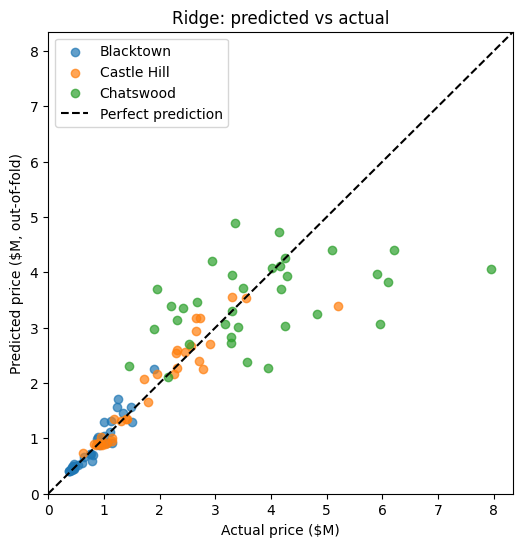

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
for s, g in df.groupby("suburb"):
    ax.scatter(g["price"] / 1e6, g["pred_price"] / 1e6, label=s, c=colors[s], alpha=0.7)

lims = [0, df[["price", "pred_price"]].max().max() / 1e6 * 1.05]
ax.plot(lims, lims, "k--", label="Perfect prediction")   # points on this line = exact
ax.set(xlim=lims, ylim=lims, xlabel="Actual price ($M)",
       ylabel="Predicted price ($M, out-of-fold)", title="Ridge: predicted vs actual")
ax.legend()
plt.show()

In [19]:
print(df.groupby("suburb")["pct_error"].apply(lambda s: s.abs().median()).round(1))

suburb
Blacktown       8.0
Castle Hill     9.1
Chatswood      28.9
Name: pct_error, dtype: float64


In [20]:
import joblib
import sklearn

# Final model: fit on ALL data (CV was only for evaluation)
final_model = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])
final_model.fit(X, y)

# Save the model plus per-suburb error so the app can show an honest range
suburb_error = (df.groupby("suburb")["pct_error"]
                  .apply(lambda s: s.abs().median()).round(1).to_dict())
joblib.dump({"model": final_model, "suburb_error": suburb_error},
            "housing_model.joblib")

print("Saved. scikit-learn version:", sklearn.__version__)

Saved. scikit-learn version: 1.5.2
